---
title: "Chapter 2: Machine Learning Fundamentals"
---

::: {.callout-lo}

By the end of this chapter, you will be able to:

- Define generalization and explain why it is a fundamental goal of supervised learning.
- Distinguish between train, validation, test, and deployment data
- Split a dataset into train and test sets using the `train_test_split` function
- Explain why performance on unseen data must be estimated using data that was not used to fit the model.
- Explain how cross-validation works and use `cross_val_score` and `cross_validate` to obtain training and validation scores.
- Diagnose underfitting and overfitting by comparing training and validation scores.
- Describe how increasing model complexity affects training error and the gap between training and validation performance.
- Apply the Golden Rule: the test set must not influence model development or selection.
- Apply a standard supervised-learning workflow: split the data, select hyperparameters using cross-validation, fit the selected model, and evaluate it once on the test set.
:::

**Imports**

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath("code"))

import mglearn
from IPython.display import HTML, display
from plotting_functions import *
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from utils import *

plt.rcParams["font.size"] = 16
pd.set_option("display.max_colwidth", 200)

%matplotlib inline

DATA_DIR = Path("data")

## Generalization

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/iS2hsRRlc2M) introduces generalization and model complexity.
:::

Supervised learning is useful because it lets us learn from examples whose targets are known and make predictions for examples whose targets are not yet known.

Consider a spam filter. We train it using past messages labelled as spam or not spam, but its real job is to classify messages that arrive tomorrow. Success on the messages it has already seen is not enough: the model must also work well on new messages.

This ability to perform well on new, relevant examples is called **generalization**.

![](img/eva-think.png)

This raises the central question of the chapter: **How can we estimate whether a model will generalize before we deploy it?**

### A motivating example: tree depth

Chapter 1 introduced decision boundaries and the `max_depth` hyperparameter of a decision tree. Increasing `max_depth` allows a tree to learn more detailed rules. Let us see what that does to its performance on the data used to fit it.

In [2]:
# Toy quiz2 grade data
classification_df = pd.read_csv(DATA_DIR / "quiz2-grade-toy-classification.csv")
classification_df.head(10)

,ml_experience,class_attendance,lab1,lab2,lab3,lab4,quiz1,quiz2
0,1,1,92,93,84,91,92,A+
1,1,0,94,90,80,83,91,not A+
2,0,0,78,85,83,80,80,not A+
3,0,1,91,94,92,91,89,A+
4,0,1,77,83,90,92,85,A+
5,1,0,70,73,68,74,71,not A+
6,1,0,80,88,89,88,91,A+
7,0,1,95,93,69,79,75,not A+
8,0,0,97,90,94,99,80,not A+
9,1,1,95,95,94,94,85,not A+


In [3]:
X = classification_df.drop(["quiz2"], axis=1)
y = classification_df["quiz2"]

In [4]:
X_subset = X[["lab4", "quiz1"]]  # Let's consider a subset of the data for visualization
X_subset.head()

,lab4,quiz1
0,91,92
1,83,91
2,80,80
3,91,89
4,92,85


#### A depth-one tree

With `max_depth=1`, the model asks one question. Its decision boundary is simple, but it makes several mistakes on the training data.

Error:   0.286


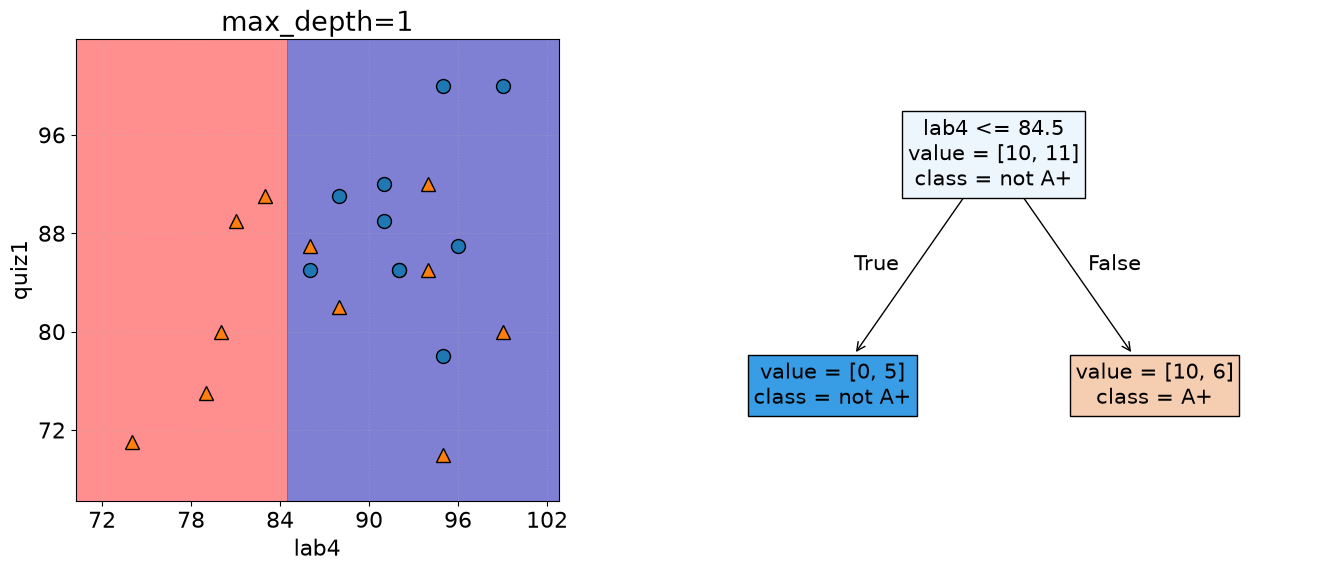

In [5]:
depth = 1
model = DecisionTreeClassifier(max_depth=depth)
model.fit(X_subset.values, y)
model.score(X_subset.values, y)
print("Error:   %0.3f" % (1 - model.score(X_subset.values, y)))
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=15
)

#### A depth-two tree

A second split creates a more detailed boundary and reduces the training error.

Error:   0.190


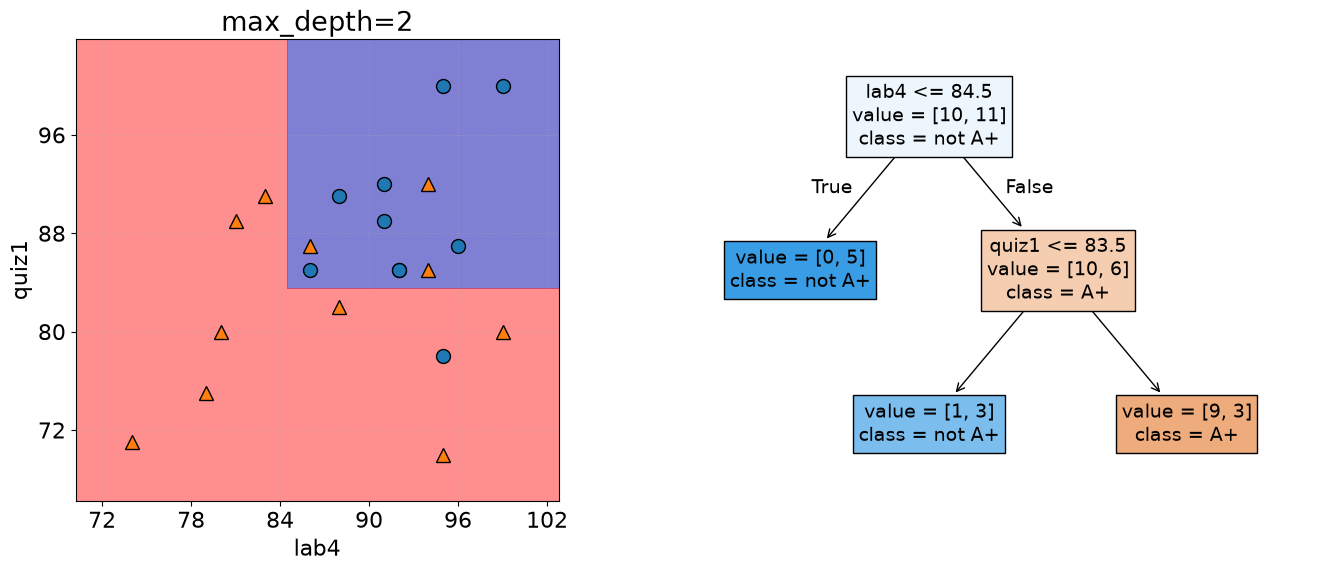

In [6]:
depth = 2
model = DecisionTreeClassifier(max_depth=depth)
model.fit(X_subset.values, y)
model.score(X_subset.values, y)
print("Error:   %0.3f" % (1 - model.score(X_subset.values, y)))
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1", fontsize=14
)

#### A depth-four tree

As depth increases, the tree can divide the feature space into smaller regions.

Error:   0.048


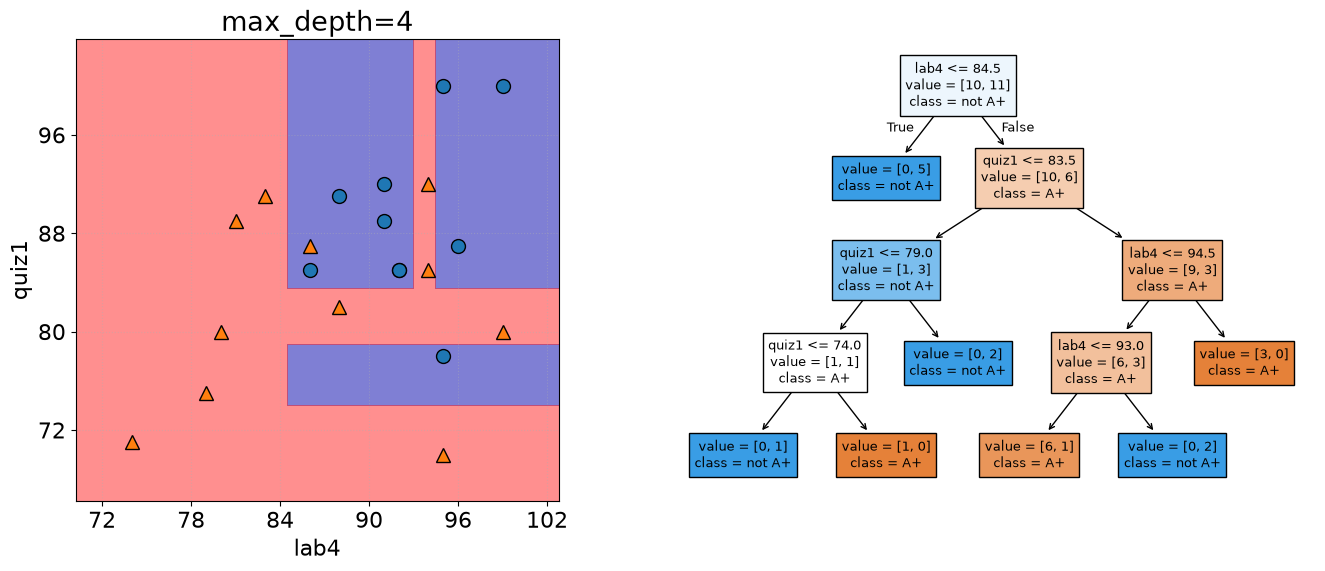

In [7]:
depth = 4
model = DecisionTreeClassifier(max_depth=depth)
model.fit(X_subset.values, y)
model.score(X_subset.values, y)
print("Error:   %0.3f" % (1 - model.score(X_subset.values, y)))
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1"
)

#### A depth-six tree

At depth six, the tree is flexible enough to classify every training example correctly.

Error:   0.000


/Users/kvarada/CS/2026-27/cpsc330-book/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


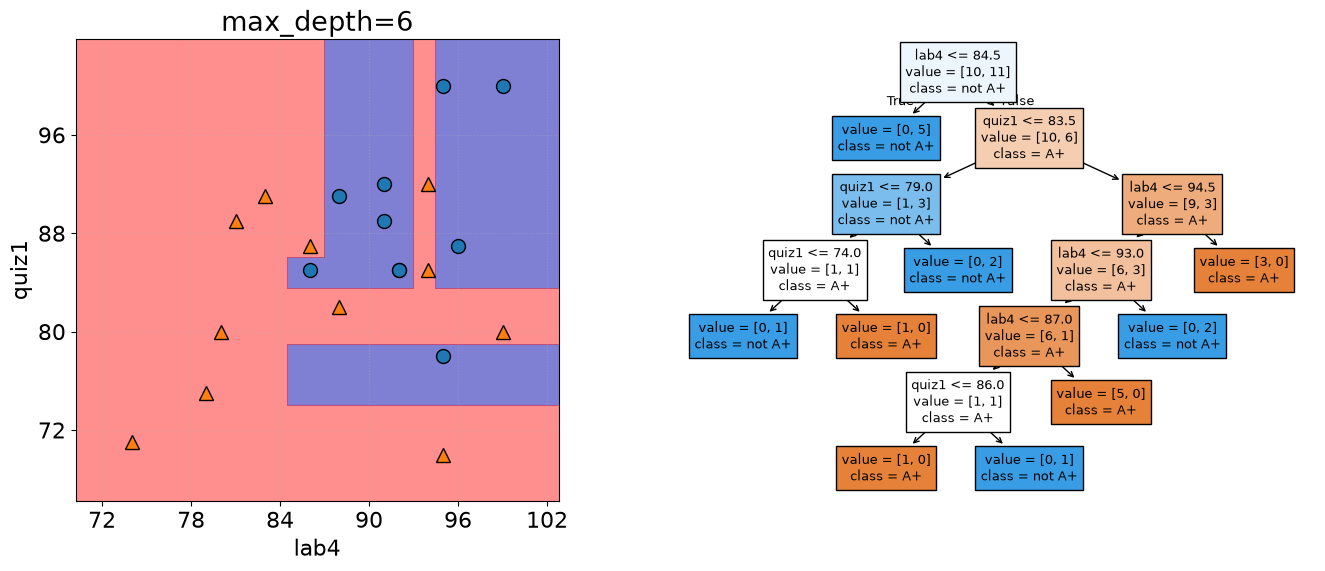

In [8]:
depth = 6
model = DecisionTreeClassifier(max_depth=depth)
model.fit(X_subset, y)
model.score(X_subset, y)
print("Error:   %0.3f" % (1 - model.score(X_subset, y)))
plot_tree_decision_boundary_and_tree(
    model, X_subset, y, x_label="lab4", y_label="quiz1"
)

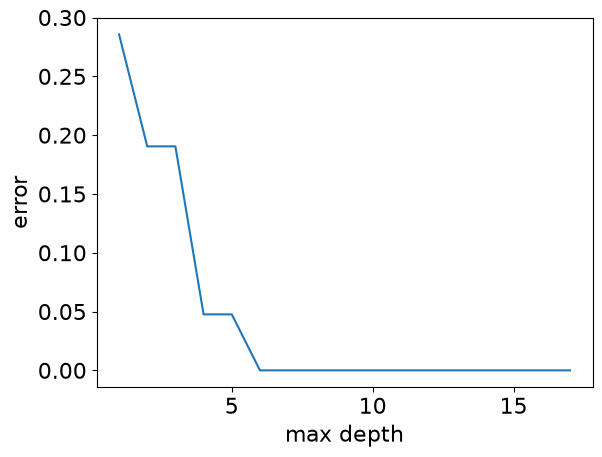

In [9]:
max_depths = np.arange(1, 18)
errors = []
for max_depth in max_depths:
    error = 1 - DecisionTreeClassifier(max_depth=max_depth).fit(X_subset, y).score(
        X_subset, y
    )
    errors.append(error)
plt.plot(max_depths, errors)
plt.xlabel("max depth")
plt.ylabel("error");

The training error reaches zero for sufficiently deep trees. That sounds ideal, but the increasingly detailed boundary may be learning peculiarities of these particular students rather than patterns that will hold for future students.

::: {.callout-reflection}
<div class="callout-reflection-title">Pause and think</div>

Would you trust the deepest tree most for predicting the grade of a student who is not in this dataset? Why or why not?
:::

### From memorization to generalization

The tree-depth example exposes a limitation of training performance: a flexible model can memorize its training examples. What we actually need is a model that captures patterns that remain useful beyond those examples.

### What does it mean to generalize?

A model **generalizes** when it makes useful predictions on new examples that are reasonably similar to the examples relevant to the problem.

The following image represents a small training set. What visual patterns might a learner use to distinguish the two labels?

![](img/generalization-train.png)

Now consider four new images. Which predictions seem reasonable based on the training examples?

![](img/generalization-predict.png)

Images  2 and 3 differ from the training images, but they share recognizable characteristics with them. Image 4 is quite different, so expecting a reliable prediction may be unreasonable.

Generalization is therefore not the ability to predict *anything*. It is the ability to perform well on new examples that are representative of the problem we intend to solve.

::: {.callout-important}
A performance estimate is meaningful only when the evaluation data resemble the data the model will encounter after deployment.
:::

### Training error and generalization error

A model can perform well on examples it has already seen but poorly on new examples. We therefore distinguish between two kinds of error:

1. **Training error:** How often the model is wrong on the examples used to fit it.
2. **Generalization error:** How often we expect the model to be wrong on new examples from the same problem.

For a spam filter, training error measures mistakes on the messages used for fitting. Generalization error describes expected performance on future messages.

We cannot observe all possible future examples. For instance, we cannot evaluate a spam filter on every email it might encounter. Instead, we estimate generalization error using representative examples that the model did not see during fitting.

## Data splitting

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/h2AEobwcUQw) introduces data splitting.
:::

### Estimating performance on unseen data

The basic idea of **data splitting** is simple:

1. Set aside some examples before fitting the model.
2. Fit the model using only the remaining examples.
3. Evaluate it on the examples that were set aside.

Because the model did not fit those held-out examples, its performance on them gives us a more realistic estimate than its training performance does.

### A train/test split

The simplest version divides the available data into two parts:

- the **training set**, used to fit the model; and
- the **test set**, held aside to evaluate the final model.

The diagram shows an 80/20 split of ten examples. We usually create this split near the beginning of a project and keep the test set in an imaginary vault until the end.

![](img/train-test-split.png)

In [10]:
# Let's demonstrate this with the canada usa cities data
# The data is available in the data directory
df = pd.read_csv(DATA_DIR / "canada_usa_cities.csv")
X = df.drop(columns=["country"])
y = df["country"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)  # 80%-20% train test split on X and y

# Print shapes
shape_dict = {
    "Data portion": ["X", "y", "X_train", "y_train", "X_test", "y_test"],
    "Shape": [
        X.shape,
        y.shape,
        X_train.shape,
        y_train.shape,
        X_test.shape,
        y_test.shape,
    ],
}

shape_df = pd.DataFrame(shape_dict)
HTML(shape_df.to_html(index=False))

Data portion,Shape
X,"(209, 2)"
y,"(209,)"
X_train,"(167, 2)"
y_train,"(167,)"
X_test,"(42, 2)"
y_test,"(42,)"


The most commonly used `train_test_split` arguments are:

- `test_size` or `train_size`, which controls the proportion assigned to each set; and
- `random_state`, which makes the random split reproducible.

#### Choosing the split size

There is no universally best split size. An 80/20 split is common, but the choice depends on how much data is available. We need enough training examples to learn useful patterns and enough test examples to obtain a meaningful final estimate.

#### Reproducible splitting

By default, `train_test_split` shuffles the rows before splitting them. Setting `random_state` fixes the random shuffle, so rerunning the code produces the same split.

::: {.callout-note}
Random splitting is not appropriate for every dataset. Time-ordered data, grouped observations, and repeated measurements require strategies that respect their structure. We will revisit these cases later.
:::

### Why do we also need validation data?

The test set is meant to evaluate the *final* model. But model development involves choices (e.g., selecting `max_depth`) that also require feedback on unseen examples. If we repeatedly use the test set to make those choices, we gradually adapt our decisions to that test set.

We therefore use a third role, **validation data**, for model and hyperparameter selection.

![](img/train-valid-test-split.png)

The three roles are:

- **Training data:** passed to `fit`; the model learns its parameters from these examples.
- **Validation data:** used to compare models and select hyperparameters; not passed to `fit` for the model being evaluated.
- **Test data:** kept untouched during model development and used once for final evaluation.

The terms vary across books and software. In this course, *validation* means data used during model development, while *test* means the final held-out data.

::: {.callout-note}
Validation data is also referred to as **development data** or **dev set** for short.  
:::

### Deployment data

After development, the model receives new examples in the real world. We call these **deployment data**. Their targets are usually unavailable at prediction time—for example, a spam filter must classify a message before a user tells us whether the prediction was correct.

Deployment performance is what we ultimately care about. Validation and test performance are useful only insofar as they help us anticipate it.

### The role of each data subset

| Data | Used with `fit`? | Used during model selection? | Main purpose |
|:---|:---:|:---:|:---|
| Training | Yes | Yes | Learn model parameters |
| Validation | No | Yes | Compare models and select hyperparameters |
| Test | No | No | Evaluate the selected model once |
| Deployment | Possibly later | No | Make predictions in the real world |

We often expect training performance to be better than validation or test performance, but there is no guaranteed ordering among these quantities. Differences also arise from random sampling.

::: {.callout-question}

<div class="exercise-title">Exercise 2.1: The roles of data subsets</div>

Select all true statements.

- (A) A low training error guarantees a low deployment error.
- (B) Data splitting helps estimate performance on unseen examples.
- (C) Validation data can be used to select `max_depth`.
- (D) Test performance can be checked repeatedly while tuning a model.
- (E) Test data should remain untouched until the model-selection process is complete.

:::

::: {.callout-tip collapse="true" title="Solution"}
B, C, and E are true. Training performance alone does not establish generalization, and repeatedly checking test performance makes the test set part of model selection.
:::

## Cross-validation

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/4cv8VYonepA) introduces cross-validation.
:::

### The limitation of one validation split

We could reserve one fixed validation set, but the result may depend heavily on which examples happen to enter it. This is especially troublesome with a small dataset: setting aside more validation data leaves fewer examples for fitting, while setting aside less makes the validation score less stable.

### $k$-fold cross-validation

**Cross-validation** reuses the training data through a sequence of temporary train/validation splits:

1. Divide the training data into $k$ groups called **folds**.
2. Fit on $k-1$ folds and validate on the remaining fold.
3. Repeat until every fold has served as the validation fold once.

The diagram illustrates four-fold cross-validation.

![](img/cross-validation.png)

Cross-validation produces $k$ validation scores. We usually report their mean and also examine their variation. The mean is typically more stable than a score from one validation split, while the variation shows how sensitive the result is to the particular fold.

Only the training portion of the original train/test split participates in cross-validation. The test set remains in the vault.

### Cross-validation using `scikit-learn`

In [12]:
from sklearn.model_selection import cross_val_score, cross_validate

#### Validation scores with `cross_val_score`

`cross_val_score` returns one validation score per fold. Here we evaluate a depth-four decision tree using ten folds.

In [13]:
model = DecisionTreeClassifier(max_depth=4)
cv_scores = cross_val_score(model, X_train, y_train, cv=10)
cv_scores

array([0.76470588, 0.82352941, 0.70588235, 0.94117647, 0.82352941,
       0.82352941, 0.70588235, 0.9375    , 0.9375    , 0.9375    ])

In [14]:
print(f"Average cross-validation score = {np.mean(cv_scores):.2f}")
print(f"Standard deviation of cross-validation score = {np.std(cv_scores):.2f}")

Average cross-validation score = 0.84
Standard deviation of cross-validation score = 0.09


For each fold, scikit-learn creates a fresh model, fits it on the fold's training portion, and scores it on the validation portion. The resulting array contains ten validation scores—one for each fitted model.

#### Training and validation scores with `cross_validate`

`cross_validate` can return additional information. Setting `return_train_score=True` lets us compare performance on each fold's training and validation portions.

In [15]:
scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)
pd.DataFrame(scores)

,fit_time,score_time,test_score,train_score
0,0.001085,0.000793,0.764706,0.913333
1,0.000821,0.000733,0.823529,0.906667
2,0.000727,0.000620,0.705882,0.906667
3,0.000702,0.000576,0.941176,0.900000
4,0.001519,0.000950,0.823529,0.906667
5,0.001432,0.000521,0.823529,0.913333
6,0.000644,0.000532,0.705882,0.920000
7,0.000923,0.000682,0.937500,0.900662
8,0.000715,0.000581,0.937500,0.900662
9,0.000639,0.000671,0.937500,0.900662


In [16]:
pd.DataFrame(pd.DataFrame(scores).mean())

,0
fit_time,0.000921
score_time,0.000666
test_score,0.840074
train_score,0.906865


::: {.callout-important}
Cross-validation evaluates a model configuration; it does not return a model ready for deployment. After choosing the hyperparameters, we fit a new model on all available training data.
:::

::: {.callout-note}
`cross_val_score` and `cross_validate` do not shuffle observations themselves. For classification, scikit-learn uses stratified folds by default so that class proportions are approximately preserved. More specialized splitting strategies are needed for time series or grouped data.
:::

### Where cross-validation fits in the workflow

At this point, our workflow is:

1. Split the available data into training and test sets.
2. Use cross-validation on the training set to compare model configurations.
3. Choose a configuration using its cross-validation results.
4. Fit that configuration on the complete training set.
5. Evaluate it once on the test set.

Before selecting a tree depth, however, we need to understand what training and validation scores tell us about model complexity.

## Underfitting, overfitting, the fundamental trade-off, and the golden rule

::: {.callout-tip title="See also"}
An [accompanying video](https://youtu.be/Ihay8yE5KTI) discusses underfitting, overfitting, and the golden rule.
:::

### Reading training and validation error

Within cross-validation, we can examine:

- $E_\textrm{train}$: mean error on the training folds; and
- $E_\textrm{valid}$: mean error on the validation folds.

Their absolute values and the gap between them help diagnose two common problems: underfitting and overfitting. We use validation—not test—performance for this diagnosis because model development is still underway.

### Underfitting

A model **underfits** when it is too simple to capture useful patterns in the training data. A depth-one decision tree illustrates this behaviour.

In [17]:
model = DecisionTreeClassifier(max_depth=1)  # decision stump
scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)
print("Train error:   %0.3f" % (1 - np.mean(scores["train_score"])))
print("Validation error:   %0.3f" % (1 - np.mean(scores["test_score"])))

Train error:   0.166
Validation error:   0.190


Both errors are relatively high, and even the training error is unsatisfactory. This is the signature of underfitting: the model cannot fit the training data well enough.

A more flexible model may reduce both training and validation error.

### Overfitting

A model **overfits** when it learns details of the training data that do not generalize. An unrestricted decision tree can keep splitting until it closely fits—or even memorizes—the training examples.

In [18]:
model = DecisionTreeClassifier(max_depth=None)
scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)
print("Train error:   %0.3f" % (1 - np.mean(scores["train_score"])))
print("Validation error:   %0.3f" % (1 - np.mean(scores["test_score"])))

Train error:   0.000
Validation error:   0.197


Here the training error is very low, but the validation error is substantially higher. This large gap is evidence of overfitting.

Low training error alone is not the problem. The problem is that performance drops considerably on examples not used for fitting.

Increasing complexity therefore does not guarantee better validation performance. Let us compare several depths systematically.

In [19]:
results_dict = {
    "depth": [],
    "mean_train_error": [],
    "mean_cv_error": [],
    "std_cv_error": [],
    "std_train_error": [],
}
param_grid = {"max_depth": np.arange(1, 16)}

for depth in param_grid["max_depth"]:
    model = DecisionTreeClassifier(max_depth=depth)
    scores = cross_validate(model, X_train, y_train, cv=10, return_train_score=True)
    results_dict["depth"].append(depth)
    results_dict["mean_cv_error"].append(1 - np.mean(scores["test_score"]))
    results_dict["mean_train_error"].append(1 - np.mean(scores["train_score"]))
    results_dict["std_cv_error"].append(scores["test_score"].std())
    results_dict["std_train_error"].append(scores["train_score"].std())

results_df = pd.DataFrame(results_dict)
results_df = results_df.set_index("depth")

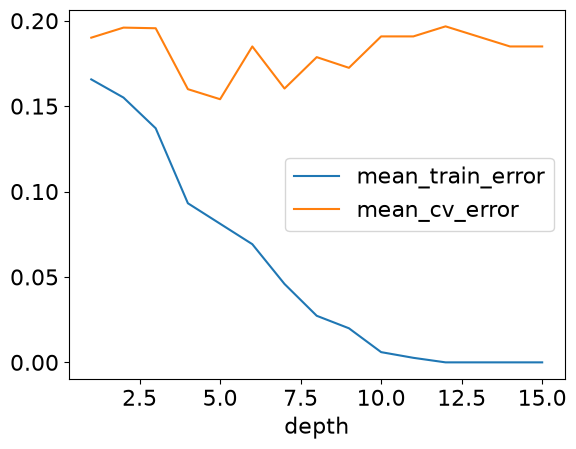

In [20]:
results_df[["mean_train_error", "mean_cv_error"]].plot();

As depth increases, training error steadily decreases. Validation error initially improves, then becomes less stable and may worsen. Deep trees have enough flexibility to encode peculiarities of individual training folds that do not carry over to their validation folds.

### The fundamental trade-off

Increasing model complexity tends to have two competing effects:

- training error decreases because the model can fit the training data more closely; and
- the gap between training and validation error tends to increase because the model becomes more sensitive to details of the training data.

We want enough complexity to capture useful patterns, but not so much that the model relies heavily on accidental ones.

### Selecting model complexity

We use cross-validation to look for a configuration that balances underfitting and overfitting. In the idealized diagram below, validation error is smallest at an intermediate level of complexity.

![](img/malp_0201.png)

[Image source](https://learning.oreilly.com/library/view/introduction-to-machine/9781449369880/ch02.html#relation-of-model-complexity-to-dataset-size)

In practice, validation scores contain sampling noise, so there may not be one obviously best value. A common starting point is to choose the hyperparameter with the best mean cross-validation score while also examining variation across folds and preferring simpler models when performance is similar.

In [21]:
results_df

,mean_train_error,mean_cv_error,std_cv_error,std_train_error
depth,,,,
1,0.165651,0.190074,0.084735,0.008808
2,0.155011,0.195956,0.085624,0.006376
3,0.137033,0.195588,0.089631,0.016135
4,0.093135,0.159926,0.090119,0.006472
5,0.081152,0.154044,0.082789,0.012076
6,0.069183,0.184926,0.060613,0.017382
7,0.045885,0.160294,0.086287,0.017165
8,0.027267,0.178676,0.090253,0.011293
9,0.019951,0.172426,0.091580,0.011527


### Final evaluation on the test set

The cross-validation results let us select `max_depth` without consulting the test set.

In [22]:
best_depth = results_df.index.values[np.argmin(results_df["mean_cv_error"])]
print(
    "The minimum validation error is %0.3f at max_depth = %d "
    % (
        np.min(results_df["mean_cv_error"]),
        best_depth,
    )
)

The minimum validation error is 0.154 at max_depth = 5 


We now fit a new decision tree with the selected depth on the full training set. Only after fitting this final model do we unlock the test set.

In [23]:
model = DecisionTreeClassifier(max_depth=best_depth)
model.fit(X_train, y_train)
print(f"Error on test set: {1 - model.score(X_test, y_test):.2f}")

Error on test set: 0.19


The test error is our final estimate of performance on new, representative examples. It may differ from the cross-validation error because both are estimates based on finite samples.

This estimate is not a guarantee of deployment performance. It depends on the test set being representative and on our having kept it independent of model development.

### The Golden Rule

::: {.callout-important}
**The test data must not influence model development or selection in any way.**
:::

Every time we use test results to change features, preprocessing, hyperparameters, or model choice, we adapt the workflow to that test set. Its score then becomes less trustworthy as an estimate of future performance.

This does not mean we ignore validation data: validation data exists specifically to guide model development. The rule is to keep the **test data** separate until the end.

### Protecting the test set

The safest habit is to create the train/test split near the start of a project and treat the test set as though it were locked in a vault.

![](img/train-test-split.png)

### A reusable supervised-learning workflow

1. **Split:** Create training and test sets before model development.
2. **Develop:** Explore the training data and build the preprocessing and modeling pipeline without using the test set.
3. **Validate:** Compare hyperparameters or models using cross-validation on the training set.
4. **Refit:** Fit the selected configuration on the complete training set.
5. **Test once:** Evaluate the final model on the test set.
6. **Deploy and monitor:** Use the model on new examples and watch for changes between development and deployment data.

We will refine this workflow throughout the course, but its separation of model development from final evaluation remains essential.

::: {.callout-question}

<div class="exercise-title">Exercise 2.2: Cross-validation and model complexity</div>

Select all true statements.

- (A) $k$-fold cross-validation fits $k$ separate models.
- (B) Cross-validation should be performed using the training set, not the held-out test set.
- (C) Much better training performance than validation performance is evidence of overfitting.
- (D) Validation error must always increase when training error decreases.
- (E) A decision stump may underfit a complicated classification problem.

:::

::: {.callout-tip collapse="true" title="Solution"}
A, B, C, and E are true. Validation error does not have to move in the opposite direction from training error; both may initially improve as complexity increases.
:::

::: {.callout-question}

<div class="exercise-title">Exercise 2.3: Diagnose the model</div>

Match each result to the most likely diagnosis.

1. Training accuracy: 0.61; validation accuracy: 0.59
2. Training accuracy: 0.99; validation accuracy: 0.68
3. Training accuracy: 0.88; validation accuracy: 0.87

Choose from **underfitting**, **overfitting**, or **neither is clearly indicated**.

:::

::: {.callout-tip collapse="true" title="Solution"}
1. **Underfitting:** even training performance is poor.  
2. **Overfitting:** there is a large training–validation gap.  
3. **Neither is clearly indicated:** the scores are similar and reasonably high, although judging whether 0.87 is adequate requires context and a baseline.
:::

::: {.callout-question}

<div class="exercise-title">Exercise 2.4: Protecting the test set</div>

You compare five values of `max_depth` using cross-validation and select `max_depth=4`. You then obtain disappointing test performance. Which action preserves the Golden Rule?

- (A) Try the other four depths on the test set and report the best result.
- (B) Return to the training data, revise the workflow using cross-validation, and acknowledge that another untouched test set would be needed for a fully unbiased final estimate.
- (C) Move the easiest test examples into the training set and evaluate again.
- (D) Report the cross-validation score as though it were the test score.

:::

::: {.callout-tip collapse="true" title="Solution"}
B. Once the test result guides further development, that test set no longer provides a clean final estimate for the revised workflow.
:::

::: {.callout-question}

<div class="exercise-title">Exercise 2.5: Put the workflow in order</div>

Arrange these steps in a sensible order:

- evaluate the final model on the test set;
- select hyperparameters using cross-validation;
- fit the selected configuration on the full training set;
- split the available data into training and test sets.

:::

::: {.callout-tip collapse="true" title="Solution"}
1. Split the data.  
2. Select hyperparameters using cross-validation on the training set.  
3. Fit the selected configuration on the full training set.  
4. Evaluate once on the test set.
:::

## Summary

This chapter introduced the central goal and evaluation workflow of supervised learning:

- **Generalization** means performing well on new, relevant examples—not merely on the training data.
- A train/test split reserves independent data for final evaluation.
- Validation data and cross-validation guide model and hyperparameter selection without exposing the test set.
- High training and validation error suggests **underfitting**; a large gap between them suggests **overfitting**.
- Increasing complexity usually lowers training error but can widen the training–validation gap.
- The **Golden Rule** keeps test data from influencing model development.
- The standard workflow is: split, develop, cross-validate, refit, test once, and then deploy and monitor.

![](img/eva-seeyou.png)